## How to get match data? 
First I need to obtain the puuid of the summoners

In [9]:
import requests
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("RIOT_API_KEY")
queue = 'RANKED_SOLO_5x5'
re_url = f'https://na1.api.riotgames.com/lol/league/v4/masterleagues/by-queue/{queue}?api_key={api_key}'
##I can get another division data using the url /lol/league/v4/entries/{queue}/{tier}/{division}

summoners = requests.get(re_url).json()
test_puuid = summoners['entries'][0]['puuid']
print(test_puuid)


4SjXfMxpQOvoGl6nj0eK9TbJqx40wVAk0McY05p3oN9QW9lVlceD1KeAZCh7qHOaFQXXC6FLOqAyBg


With the puuid I can use other endpoint to get match IDs in the range of time

In [19]:
from datetime import datetime

min_match = 0
max_match = 100
start_time = '2026-01-01' #The older match they have is June 16th, 2021 according to the doc
end_time = '2026-07-13'
start_time_epoch = int(datetime.strptime(start_time+'T00:00:00Z', '%Y-%m-%dT%H:%M:%SZ').timestamp()) #Epoch timestamp
end_time_epoch = int(datetime.strptime(end_time+'T00:00:00Z', '%Y-%m-%dT%H:%M:%SZ').timestamp()) #Epoch timestamp
queue = 420 #The ID for RANKED_SOLO_5x5
re_url = f'https://americas.api.riotgames.com/lol/match/v5/matches/by-puuid/{test_puuid}/ids?start={min_match}&count={max_match}&queue={queue}&startTime={start_time_epoch}&endTime={end_time_epoch}&api_key={api_key}'

response = requests.get(re_url)
if response.status_code == 200:
    matches_id_list = response.json()
    print(len(matches_id_list))
    if len(matches_id_list) > 0:
        test_match_id = matches_id_list[0]
        print(test_match_id)
else:
    print(f"Error: {response.status_code} - {response.text}")

100
NA1_5600544468


Finally, I get the details of the match result:

In [8]:
re_url = f'https://americas.api.riotgames.com/lol/match/v5/matches/{test_match_id}?api_key={api_key}'

match_data = requests.get(re_url).json()
print(match_data)
#Champions used
print(match_data['info']['participants'][0]['championName'])
#Which items were used
print(match_data['info']['participants'][1]['item0'])

{'metadata': {'dataVersion': '2', 'matchId': 'NA1_5596875739', 'participants': ['UT5MxmsGPOdLpW-LsJ0JV5ImvrirYFf-pW1HWL1WGHJ57BqsoReAHHPtzfQVdCg8TVdtRS1qNCVgtQ', 'qyF8P5r-3YGt3vjxiKHK1HLeCQp_O3hC-Ct4W9aVpZXaPuB40wjMcjoUhP-puNalaAtHtRtomPg4nw', 'GXQtRfpZ1Z5VYj3p0blxSBaWqbPo3RJDY4qbB5V1pJHHcf1nQa_yFv-yuj2LXP8EpvrqNpQN46HYBQ', 'F4E1OVj2JNBeKD_vSiOyJCb-u3g9zPQICzO4u-SwRu2eFSUy6yJlNEQGqtt3dWmPd8T0Utkt3SyxOw', '617Xk7JNbM-Gm1Wo3DtvELAQOdQVL47QeaPY_WuD3LSoIU9jdfz2FtIKRm4bBaDyGKk02LIjr2HTOw', 'pOTt4s6VPIwiUxqsJqa9ffEX_7PhuRc7hstUn3QHBvzw1kIr6okClOk4hXgaKsZlJe1XIirKlBixkQ', '05pcb4reO3ky4FjR-tHTOzrZr8vnd481mZ5mu5vCBJr_sFbzcYj88byK48GRF_OPeRI-bsG8sfJsaw', 'gw0hn0yQHYvjKQ3PMhctjEXZRk0RDNj5VAYI6xgrBRBzvoXKrj58WScY-7wumOWsyjIWmNBusHJEzA', 'NAZy7qZ8XFgzjEx3FkOqujRChATOXdy4sZroTg3rLe1Kudvroteg4PIJWmTDAkoe0ODuGK84-DiDMA', 'r0Dh7eGD3IaLMwbZQjOx2oAUJ7UGJrTMmSKsoCJQzJsyqtVIgApDVLWa-wX2pTuBNEfR_a6zUctEZQ']}, 'info': {'endOfGameResult': 'GameComplete', 'gameCreation': 1783419488834, 'gameDuration': 1418, '

## Questions with the Summoner Data
### Q1. Can I use inactive and  freshBlood parameters to get new summoners?

Let's explore is this fields are populated in the data. But first, I need to crear a dataset with the jsons

In [42]:
import pandas as pd

source_route = "../datasets/bronze/riot_api"
print(f"Loading from: {source_route}")

divisions = ['IRON', 'BRONZE', 'SILVER', 'GOLD', 'PLATINUM', 'DIAMOND']
high_divisions = ['MASTER', 'GRANDMASTER', 'CHALLENGER']
tiers = ['IV', 'III', 'II', 'I']
summoners_df = pd.DataFrame()

for division in divisions:
    for tier in tiers:
        file_path = f"{source_route}/summoners_{division}_{tier}.json"
        try:
            df = pd.read_json(file_path, orient='records', lines=True)
            summoners_df = pd.concat([summoners_df, df], ignore_index=True)
        except FileNotFoundError:
            print(f"File not found: {file_path}. Skipping.")

for high_division in high_divisions:
    file_path = f"{source_route}/summoners_{high_division}_I.json"
    try:
        df = pd.read_json(file_path, orient='records', lines=True)
        df['queueType'] = 'RANKED_SOLO_5x5'
        df['tier'] =high_division
        summoners_df = pd.concat([summoners_df, df], ignore_index=True)
    except FileNotFoundError:
        print(f"File not found: {file_path}. Skipping.")

print(summoners_df.head())
print(f"Total summoners loaded: {len(summoners_df)}")

Loading from: ../datasets/bronze/riot_api
         queueType  tier rank  \
0  RANKED_SOLO_5x5  IRON   IV   
1  RANKED_SOLO_5x5  IRON   IV   
2  RANKED_SOLO_5x5  IRON   IV   
3  RANKED_SOLO_5x5  IRON   IV   
4  RANKED_SOLO_5x5  IRON   IV   

                                               puuid  leaguePoints  wins  \
0  zbNJhVhzdtnQG3s0gd5inE-akE76_4Ig9H5a0_c5A15FyE...            59    27   
1  s1nF5LlzN20BMu8T-JI53gzsbrs4ayIzyTnslzQNHiB_cv...            20   212   
2  -Fo1FzTUMzcnl2sofLxGmr4qGhMDrFuCNpJWiif9t5I6yx...            47   157   
3  3zJZwWCeMV9tKpduexAe9HPMlcUNLh56UMCUUmyiL73Txj...            57    22   
4  55ecrVaSnffPRyPBBr7yxAaDdE98irpml1YiKBmiTD4PWe...            76    14   

   losses  veteran  inactive  freshBlood  hotStreak  
0      64    False     False       False      False  
1     267    False     False       False      False  
2     187    False     False       False      False  
3      41    False     False       False      False  
4      28    False     False    

In [ ]:
print('----- Fresh Blood')
print(summoners_df.freshBlood.value_counts())
print(summoners_df[summoners_df.freshBlood == True].iloc[1].puuid)
print('---------------\n')

print('----- Veteran')
print(summoners_df.veteran.value_counts())
print(summoners_df[summoners_df.veteran == True].iloc[1].puuid)
print('---------------\n')

print('-----There is a fresh blood and veteran?')
print(len(summoners_df[(summoners_df.freshBlood == True) & (summoners_df.veteran == True)]))
print('---------------\n')

print('----- Inactive')
print(summoners_df.inactive.value_counts())
#print(summoners_df[summoners_df.inactive == True].iloc[1].puuid)
print('---------------\n')


print('----- Hot Streak')
print(summoners_df.hotStreak.value_counts())
print(summoners_df[summoners_df.hotStreak == True].iloc[1].puuid)
print('---------------\n')


----- Fresh Blood
freshBlood
False    1197574
True       79593
Name: count, dtype: int64
1ZkJUbX6KpUbwBQFJPbtMqqmYU7sUEq48xQGOXRDegr8jlmtKYr0dmKxCiLwzFAugMXIFvGYtFmaTQ
---------------

----- Veteran
veteran
False    1273845
True        3322
Name: count, dtype: int64
abKpHG38lfjagiucyLG9tRtaLxf0lyojGGBhXb9KTqjt0QGnxJQ7CDrGEwO0bChwgGifxLCKDRsF8g
---------------

-----There is a fresh blood and veteran?
        queueType tier rank  \
1267380       NaN  NaN    I   

                                                     puuid  leaguePoints  \
1267380  3kZczlxVFTuGyqRycVtOJiYKfqGNTT4ZAOSjgDTU9Ap1Fj...           567   

         wins  losses  veteran  inactive  freshBlood  hotStreak  
1267380   279     265     True     False        True       True  
None
---------------

----- Inactive
inactive
False    1277167
Name: count, dtype: int64
---------------

----- Hot Streak
hotStreak
False    1148473
True      128694
Name: count, dtype: int64
LRnAIMCTpgMKKvI8FVNrwRYWri5Y9EkxgVPHU61Tv479o-8KSzXbDJf


### A1: 
**freshBlood** is if the player is new to that division. But I can work with that in the future and filter the ones that already exist in the DB

There's not **inactive** account.

### Q2:

Which is the distribution between divisions.

               count percent
IRON          52,481   4.11%
BRONZE       240,894  18.86%
SILVER       317,923  24.89%
GOLD         347,629  27.22%
PLATINUM     254,728  19.94%
DIAMOND       52,486   4.11%
MASTER        10,000   0.78%
GRANDMASTER      724   0.06%
CHALLENGER       302   0.02%


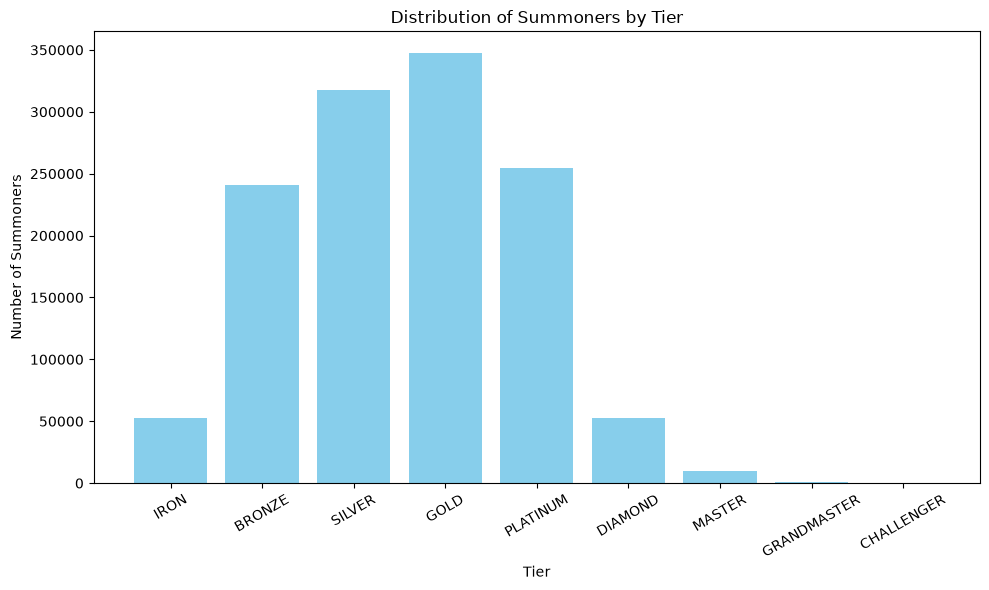

In [49]:
import matplotlib.pyplot as plt

order = ['IRON', 'BRONZE', 'SILVER', 'GOLD', 'PLATINUM', 'DIAMOND', 'MASTER', 'GRANDMASTER', 'CHALLENGER']

# Reorder data to match the intended tier order
count = summoners_df["tier"].value_counts().reindex(order, fill_value=0)
percentage = (count / count.sum() * 100).round(2)

resumen_tier = pd.DataFrame({
    "count": count.map(lambda x: f"{x:,}"),
    "percent": percentage.map(lambda x: f"{x:.2f}%")
}, index=order)

print(resumen_tier)

plt.figure(figsize=(10, 6))
plt.bar(order, count.values, color='skyblue')
plt.title("Distribution of Summoners by Tier")
plt.xlabel("Tier")
plt.ylabel("Number of Summoners")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Q3
Which is the win rate of every division?

tier
IRON           0.416139
BRONZE         0.469002
SILVER         0.487691
GOLD           0.497407
PLATINUM       0.505732
DIAMOND        0.518604
MASTER         0.518297
GRANDMASTER    0.532841
CHALLENGER     0.549884
dtype: float64


([0, 1, 2, 3, 4, 5, 6, 7, 8],
 [Text(0, 0, 'IRON'),
  Text(1, 0, 'BRONZE'),
  Text(2, 0, 'SILVER'),
  Text(3, 0, 'GOLD'),
  Text(4, 0, 'PLATINUM'),
  Text(5, 0, 'DIAMOND'),
  Text(6, 0, 'MASTER'),
  Text(7, 0, 'GRANDMASTER'),
  Text(8, 0, 'CHALLENGER')])

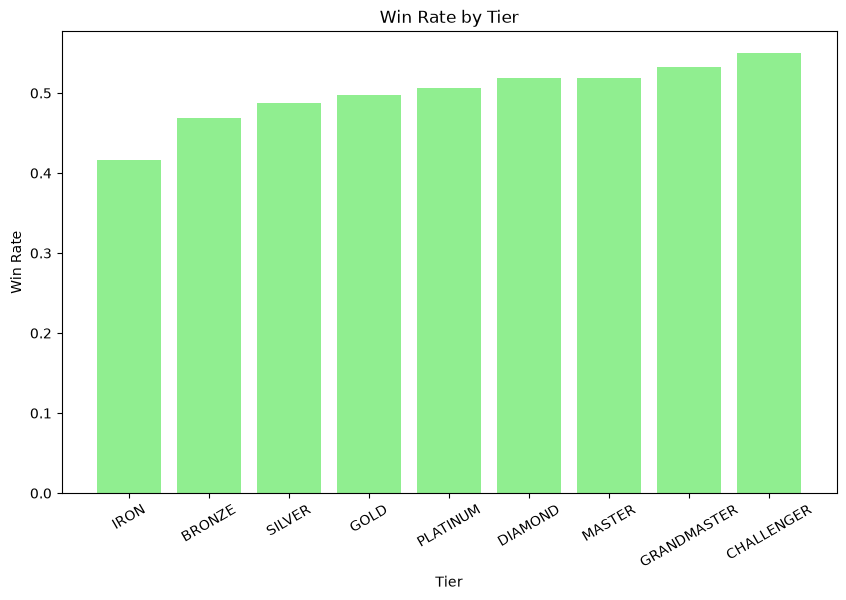

In [53]:
import matplotlib.pyplot as plt

order = ['IRON', 'BRONZE', 'SILVER', 'GOLD', 'PLATINUM', 'DIAMOND', 'MASTER', 'GRANDMASTER', 'CHALLENGER']

win_rate = summoners_df.groupby('tier')['wins'].sum() / (summoners_df.groupby('tier')['losses'].sum() + summoners_df.groupby('tier')['wins'].sum())
win_rate = win_rate.reindex(order, fill_value=0)
print(win_rate)

plt.figure(figsize=(10, 6))
plt.bar(order, win_rate.values, color='lightgreen')
plt.title("Win Rate by Tier")
plt.xlabel("Tier")
plt.ylabel("Win Rate")
plt.xticks(rotation=30)